# Peramalan Kadar $NO_2$ di Daerah Manado Menggunakan KNN Regression

## Latar Belakang

Kualitas udara menjadi salah satu hal yang perlu diperhatikan karena berhubungan dengan kesehatan dan lingkungan. Salah satu zat pencemar udara yang sering diamati adalah Nitrogen Dioksida atau $NO_2$. Gas ini biasanya berasal dari aktivitas kendaraan, industri, dan proses pembakaran bahan bakar.

Pada penelitian ini, data kadar $NO_2$ digunakan dalam bentuk time series harian. Data yang digunakan adalah data selama tiga bulan, yaitu dari 1 Maret 2026 sampai 31 Mei 2026. Karena bentuknya time series, nilai pada suatu hari bisa dipengaruhi oleh nilai pada hari-hari sebelumnya.

Contohnya, untuk memprediksi kadar $NO_2$ hari ketiga, model dapat menggunakan data hari pertama dan hari kedua. Oleh karena itu, data akan diubah menjadi bentuk supervised agar dapat digunakan pada model KNN Regression.

## 1. Pengumpulan Data

Pada tahap ini dilakukan pengambilan data kadar $NO_2$ menggunakan layanan Copernicus Data Space Ecosystem melalui OpenEO. Data yang digunakan berasal dari satelit Sentinel-5P dengan koleksi `SENTINEL_5P_L2`.

Data diambil untuk wilayah Manado dengan rentang waktu 1 Maret 2026 sampai 31 Mei 2026. Karena data berasal dari Copernicus, pengguna perlu melakukan autentikasi terlebih dahulu menggunakan akun Copernicus.

In [ ]:
!pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.9 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


Library `openeo` digunakan untuk menghubungkan Python dengan server Copernicus. Setelah library berhasil dipasang, koneksi dibuat ke server `openeo.dataspace.copernicus.eu`.

Saat kode koneksi dijalankan, akan muncul link autentikasi. Link tersebut dibuka untuk login menggunakan akun Copernicus. Jika login berhasil, proses pengambilan data bisa dilanjutkan.

In [ ]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=SBPF-KONA 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Setelah berhasil terhubung dengan server Copernicus, langkah berikutnya adalah menentukan area penelitian. Area penelitian ditulis dalam bentuk polygon GeoJSON.

Koordinat yang digunakan memiliki format `[longitude, latitude]`. Polygon ini berfungsi sebagai batas wilayah Manado yang akan diambil data kadar $NO_2$-nya.

In [ ]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [124.8263984, 1.5395409],
            [124.843767, 1.5187742],
            [124.8403614, 1.4983477],
            [124.8291229, 1.4843895],
            [124.8301446, 1.468048],
            [124.818225, 1.4595368],
            [124.8914453, 1.4561323],
            [124.8948509, 1.5402218],
            [124.8263984, 1.5395409],
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2026-03-01", "2026-06-01"],
    spatial_extent={
        "west": 124.818225,
        "south": 1.4561323,
        "east": 124.8948509,
        "north": 1.5402218
    },
    bands=["NO2"],
)

# Aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Create a spatial aggregation to generate mean time series data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

job = s5p_no2_daily.execute_batch(
    title="NO2 in Manado March May 2026",
    outputfile="NO2Manado_Maret_Mei.nc"
)

0:00:00 Job 'j-260603064159460eac252d85e44c3ca2': send 'start'
0:00:06 Job 'j-260603064159460eac252d85e44c3ca2': queued (progress 0%)
0:00:12 Job 'j-260603064159460eac252d85e44c3ca2': queued (progress 0%)
0:00:18 Job 'j-260603064159460eac252d85e44c3ca2': queued (progress 0%)
0:00:26 Job 'j-260603064159460eac252d85e44c3ca2': queued (progress 0%)
0:00:36 Job 'j-260603064159460eac252d85e44c3ca2': queued (progress 0%)
0:00:49 Job 'j-260603064159460eac252d85e44c3ca2': queued (progress 0%)
0:01:04 Job 'j-260603064159460eac252d85e44c3ca2': queued (progress 0%)
0:01:24 Job 'j-260603064159460eac252d85e44c3ca2': running (progress N/A)
0:01:48 Job 'j-260603064159460eac252d85e44c3ca2': running (progress N/A)
0:02:18 Job 'j-260603064159460eac252d85e44c3ca2': finished (progress 100%)


Pada kode di atas, variabel `aoi` digunakan untuk menentukan area penelitian dalam bentuk polygon GeoJSON. Koordinat yang digunakan memiliki format `[longitude, latitude]`.

Setelah area ditentukan, data diambil dari koleksi `SENTINEL_5P_L2` dengan band `NO2`. Rentang waktu yang digunakan adalah 1 Maret 2026 sampai 31 Mei 2026. Pada bagian `temporal_extent`, tanggal akhir ditulis `2026-06-01` agar data sampai 31 Mei tetap ikut terambil.

Data kemudian diagregasi menjadi data harian menggunakan nilai rata-rata. Hal ini dilakukan karena dalam satu hari bisa terdapat lebih dari satu data pengamatan. Setelah itu, proses pengambilan data dijalankan menggunakan `execute_batch`, dan hasilnya disimpan dalam file `NO2Manado_Maret_Mei.nc`.

## 2. Preprocessing Data

Setelah data berhasil diambil, file yang diperoleh masih berbentuk `.nc` atau NetCDF. File ini perlu dibaca terlebih dahulu agar data $NO_2$ dan tanggalnya bisa diolah.

Pada tahap ini, data akan dibuat menjadi time series harian. Data yang awalnya masih berbentuk grid akan dirata-ratakan, sehingga setiap tanggal hanya memiliki satu nilai kadar $NO_2$.

In [ ]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.3 MB/s eta 0:00:00


In [ ]:
import netCDF4

file_path = "NO2Manado_Maret_Mei.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time

# Tampilkan struktur data NO2
print(type(no2))
print(len(no2))
print(len(no2[0]))
print(len(no2[0][0]))
print(no2[0][0][0])

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
91
3
2
--


Dari kode di atas, kita bisa melihat bentuk data pada variabel `NO2`. Data tersebut masih berbentuk array tiga dimensi, yaitu waktu, baris grid, dan kolom grid.

Jadi, dalam satu tanggal masih terdapat beberapa nilai $NO_2$ sesuai grid wilayah. Karena itu, data perlu dirata-ratakan agar satu tanggal hanya mempunyai satu nilai.

In [ ]:
print("Contoh data pertama:")

for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[-- --]
 [-- --]
 [-- --]]
[[-- --]
 [-- --]
 [-- --]]
[[1.1914274182345252e-05 1.1914274182345252e-05]
 [2.1418120468297275e-06 --]
 [8.290666301036254e-06 --]]
[[5.996263553242898e-06 5.996263553242898e-06]
 [-- --]
 [-- --]]
[[-- --]
 [-- --]
 [-- --]]
[[-- 1.8844350051949732e-05]
 [-- --]
 [1.175246052298462e-05 --]]
[[-- --]
 [-- --]
 [-- --]]
[[-- --]
 [-- --]
 [-- --]]
[[3.4173444873886183e-06 --]
 [4.62401112599764e-06 2.2682370399706997e-06]
 [-- --]]
[[-- --]
 [-- --]
 [-- --]]


### a. Mengatasi Missing Value dengan Interpolasi Linear

Pada data $NO_2$, terdapat kemungkinan nilai kosong atau missing value. Nilai kosong ini biasanya muncul karena tidak semua grid memiliki data pada waktu tertentu.

Pada tahap ini dilakukan interpolasi linear untuk mengisi missing value pada data NO2. Nilai kosong pada file NetCDF biasanya terbaca sebagai masked value atau tanda `--`, sehingga terlebih dahulu diubah menjadi `NaN`. Setelah itu, interpolasi dilakukan pada setiap grid wilayah berdasarkan urutan waktu. Dengan cara ini, nilai NO2 yang kosong dapat diperkirakan dari nilai sebelum dan sesudahnya.

In [ ]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2, dtype=float)

# Ubah nilai '--' / masked value menjadi NaN
no2_array = np.ma.filled(no2, np.nan)

# loop tiap grid (y,x)
for i in range(no2_array.shape[1]):
    for j in range(no2_array.shape[2]):
        series = pd.Series(no2_array[:, i, j], dtype="float64")

        no2_filled[:, i, j] = series.interpolate(
            method="linear",
            limit_direction="both"
        ).to_numpy()

print("Jumlah missing setelah interpolasi grid:", np.isnan(no2_filled).sum())

Jumlah missing setelah interpolasi grid: 0


### b. Merata-ratakan Data dan Mengubah Format Tanggal

Setelah missing value pada grid ditangani, data $NO_2$ dirata-ratakan untuk setiap tanggal. Tujuannya agar satu tanggal hanya memiliki satu nilai kadar $NO_2$.

Format tanggal juga diubah menjadi bentuk `YYYY-MM-DD` agar lebih mudah digunakan sebagai data time series harian.

In [ ]:
new_dates = []
new_no2 = []

for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

    # rata-rata NO2 per tanggal
    new_no2.append(np.nanmean(no2_filled[i]))

### c. Simpan Data dalam Bentuk CSV

Setelah tanggal dan nilai rata-rata $NO_2$ didapatkan, data dibuat menjadi DataFrame Pandas. Data ini kemudian disimpan dalam bentuk CSV agar lebih mudah digunakan pada tahap berikutnya.

In [ ]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_Manado_Maret_Mei.csv", index=False)

### d. Pengecekan Missing Value Data Harian pada CSV

Setelah data berbentuk CSV, perlu dicek apakah data harian dari 1 Maret 2026 sampai 31 Mei 2026 sudah lengkap. Jika ada tanggal yang hilang, maka tanggal tersebut akan muncul pada daftar missing date.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Manado_Maret_Mei.csv")

# Pastikan kolom date bertipe datetime
df["date"] = pd.to_datetime(df["date"])

# Buat rentang tanggal lengkap
start_date = "2026-03-01"
end_date = "2026-05-31"

full_range = pd.date_range(start=start_date, end=end_date, freq="D")

# Cek tanggal yang hilang
missing_dates = full_range.difference(df["date"])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 1
Daftar tanggal missing:
DatetimeIndex(['2026-04-15'], dtype='datetime64[ns]', freq='D')


Jika terdapat tanggal yang hilang, maka data akan dibuat ulang berdasarkan rentang tanggal lengkap. Tanggal yang belum memiliki nilai $NO_2$ akan diisi menggunakan interpolasi berdasarkan waktu.

Bagian ini penting karena data time series harus tetap berurutan dan tidak boleh ada tanggal yang terlewat.

In [ ]:
import pandas as pd

# Pastikan datetime dan sorting
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2026-03-01", end="2026-05-31", freq="D")

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index("date").reindex(full_range)
df.index.name = "date"

# Interpolasi linear berdasarkan indeks waktu
df["NO2"] = df["NO2"].interpolate(method="time")

# Jika masih ada NaN di awal/akhir, isi dengan backward/forward fill
df["NO2"] = df["NO2"].bfill().ffill()

# Ubah kembali index menjadi kolom
df = df.reset_index()

# Simpan kembali ke CSV
df.to_csv("no2_manado_maret_mei_interpolated.csv", index=False)

In [ ]:
df_check = pd.read_csv("no2_manado_maret_mei_interpolated.csv")

df_check["date"] = pd.to_datetime(df_check["date"])

full_range_check = pd.date_range(
    start="2026-03-01",
    end="2026-05-31",
    freq="D"
)

missing_dates_check = full_range_check.difference(df_check["date"])

print(f"Jumlah hari missing: {len(missing_dates_check)}")
print("Daftar tanggal missing:")
print(missing_dates_check)

print("Jumlah missing value NO2:", df_check["NO2"].isna().sum())

Jumlah hari missing: 0
Daftar tanggal missing:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')
Jumlah missing value NO2: 0


### e. Deteksi Outlier IQR

Setelah missing value ditangani, tahap berikutnya adalah mendeteksi outlier menggunakan metode IQR. Outlier adalah nilai yang terlalu jauh dari pola data umum.

Karena data ini merupakan time series, outlier tidak langsung dihapus begitu saja. Nilai outlier akan ditandai sebagai kosong, lalu diisi kembali menggunakan interpolasi linear agar urutan tanggal tetap lengkap.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_manado_maret_mei_interpolated.csv")

df["date"] = pd.to_datetime(df["date"])

# Hitung IQR
Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df["NO2"] < lower_bound) | (df["NO2"] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[["date", "NO2"]].head())

Jumlah Outlier (IQR): 3
         date       NO2
34 2026-04-04  0.000016
38 2026-04-08  0.000002
39 2026-04-09  0.000004


Untuk melihat posisi outlier pada data, dibuat visualisasi. Titik merah menunjukkan nilai yang terdeteksi sebagai outlier. Garis batas atas dan bawah menunjukkan batas nilai berdasarkan perhitungan IQR.

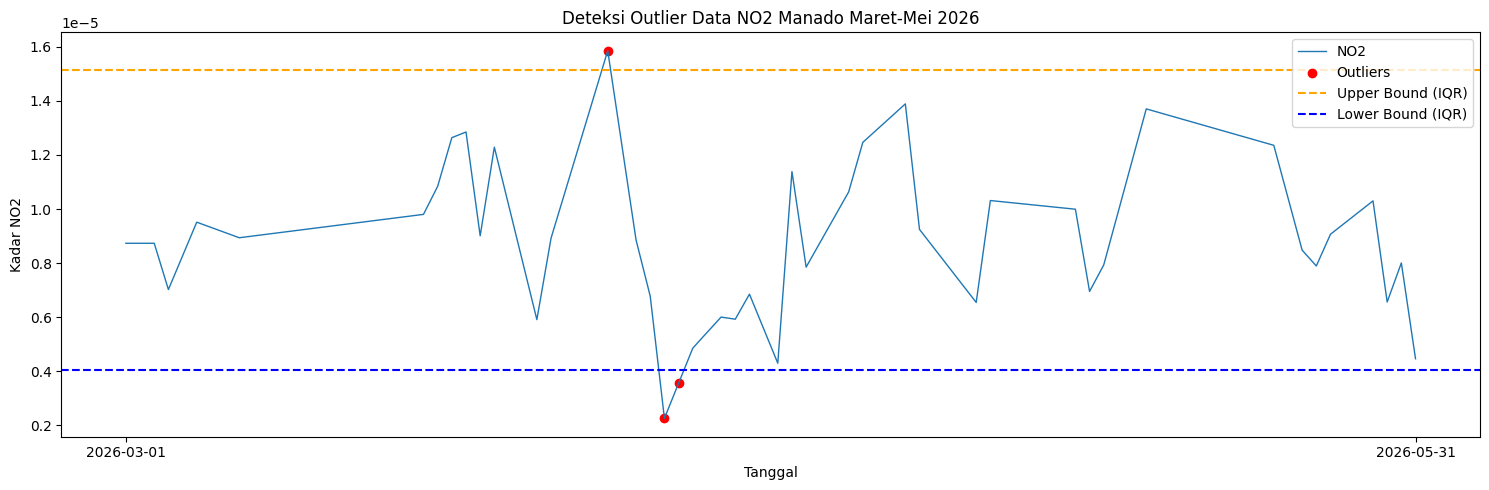

In [ ]:
# Visualisasi outlier
plt.figure(figsize=(15, 5))
plt.plot(df["date"], df["NO2"], label="NO2", linewidth=1)

plt.scatter(
    outliers_iqr["date"],
    outliers_iqr["NO2"],
    color="red",
    marker="o",
    label="Outliers"
)

plt.axhline(
    upper_bound,
    color="orange",
    linestyle="dashed",
    label="Upper Bound (IQR)"
)

plt.axhline(
    lower_bound,
    color="blue",
    linestyle="dashed",
    label="Lower Bound (IQR)"
)

plt.title("Deteksi Outlier Data NO2 Manado Maret-Mei 2026")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()

plt.xticks(
    ticks=[df["date"].iloc[0], df["date"].iloc[-1]],
    labels=[
        df["date"].iloc[0].strftime("%Y-%m-%d"),
        df["date"].iloc[-1].strftime("%Y-%m-%d")
    ]
)

plt.show()

In [ ]:
# Tandai outlier menjadi NaN
df["NO2_cleaned"] = df["NO2"].mask(
    (df["NO2"] < lower_bound) | (df["NO2"] > upper_bound)
)

print("Jumlah nilai yang dinyatakan sebagai outlier:", df["NO2_cleaned"].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df["NO2_filled"] = df["NO2_cleaned"].interpolate(method="linear")

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df["NO2_filled"] = df["NO2_filled"].bfill().ffill()

print("Jumlah missing setelah interpolasi:", df["NO2_filled"].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 3
Jumlah missing setelah interpolasi: 0


Setelah outlier ditangani, data divisualisasikan kembali. Grafik ini menunjukkan kondisi data setelah nilai ekstrem diganti menggunakan interpolasi linear.

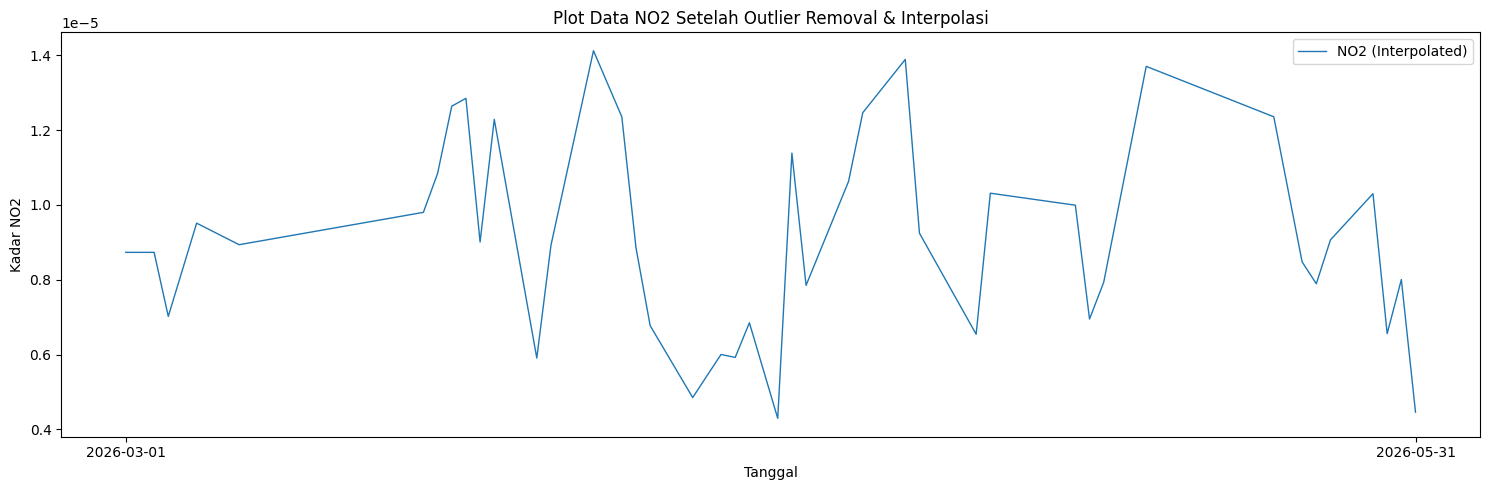

In [ ]:
plt.figure(figsize=(15, 5))

# Plot data hasil interpolasi
plt.plot(
    df["date"],
    df["NO2_filled"],
    label="NO2 (Interpolated)",
    linewidth=1
)

# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df["date"].iloc[0], df["date"].iloc[-1]],
    labels=[
        df["date"].iloc[0].strftime("%Y-%m-%d"),
        df["date"].iloc[-1].strftime("%Y-%m-%d")
    ]
)

plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

# Simpan data akhir preprocessing
df_final = df[["date", "NO2_filled"]].rename(
    columns={"NO2_filled": "NO2"}
)

df_final.to_csv("NO2_Manado_Maret_Mei_final.csv", index=False)

## 3. Modeling Menggunakan KNN Regression

Setelah preprocessing selesai, data time series diubah menjadi bentuk supervised. Maksudnya, data yang awalnya hanya berisi tanggal dan nilai $NO_2$ akan diubah menjadi data dengan fitur dan target.

Konsep yang digunakan adalah lag. Nilai $NO_2$ hari ini diprediksi berdasarkan nilai $NO_2$ pada hari-hari sebelumnya. Misalnya, untuk memprediksi hari ketiga, model memakai data hari pertama dan hari kedua.

Bentuk sederhananya:

$NO_2(t-2), NO_2(t-1) \rightarrow NO_2(t)$

Model yang digunakan adalah KNN Regression karena target yang diprediksi berupa nilai numerik.

### a. Normalisasi Data

Sebelum masuk ke model KNN Regression, data perlu dinormalisasi. Hal ini dilakukan karena KNN bekerja berdasarkan jarak antar data. Dengan normalisasi, nilai $NO_2$ diubah ke rentang 0 sampai 1.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

df = pd.read_csv("NO2_Manado_Maret_Mei_final.csv")

df["date"] = pd.to_datetime(df["date"])

# Pastikan tidak ada missing value
df["NO2"] = df["NO2"].interpolate(method="linear")
df["NO2"] = df["NO2"].bfill().ffill()

scaler = MinMaxScaler()

df["NO2_scaled"] = scaler.fit_transform(df[["NO2"]])

df.head()

,date,NO2,NO2_scaled
0,2026-03-01,0.000009,0.451507
1,2026-03-02,0.000009,0.451507
2,2026-03-03,0.000009,0.451507
3,2026-03-04,0.000007,0.277316
4,2026-03-05,0.000008,0.404135


### b. Mengubah Data Time Series Menjadi Supervised

Data time series perlu diubah menjadi data supervised agar bisa dipakai pada model machine learning. Pada bagian ini dibuat fungsi `create_supervised`.

Jika `n_lag=2`, maka model menggunakan dua hari sebelumnya sebagai fitur untuk memprediksi hari ini.

In [ ]:
import pandas as pd

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    # Membuat fitur t-n sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f"NO2(t-{i})"] = data.shift(i)

    # Label hari H
    df_supervised["NO2(t)"] = data

    # Hapus baris yang masih mengandung NaN akibat shift
    df_supervised.dropna(inplace=True)

    return df_supervised

### c. Uji Korelasi Data

Sebelum training model, dilakukan uji korelasi untuk melihat hubungan antara nilai $NO_2$ pada hari-hari sebelumnya dengan nilai $NO_2$ hari ini. Semakin besar nilai korelasi, maka hubungan antara fitur dan target semakin kuat.

In [ ]:
# Contoh penggunaan untuk melihat korelasi sampai 30 hari sebelumnya
supervised_df30 = create_supervised(df["NO2_scaled"], n_lag=30)

lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30["NO2(t)"])

print(correlations)

NO2(t-30)   -0.071776
NO2(t-29)   -0.011945
NO2(t-28)   -0.007655
NO2(t-27)   -0.021922
NO2(t-26)   -0.055847
NO2(t-25)   -0.046794
NO2(t-24)   -0.000248
NO2(t-23)    0.088565
NO2(t-22)    0.097812
NO2(t-21)    0.176751
NO2(t-20)    0.163777
NO2(t-19)    0.050618
NO2(t-18)   -0.057126
NO2(t-17)   -0.126606
NO2(t-16)   -0.220130
NO2(t-15)   -0.271711
NO2(t-14)   -0.275677
NO2(t-13)   -0.313620
NO2(t-12)   -0.236333
NO2(t-11)   -0.177172
NO2(t-10)   -0.131185
NO2(t-9)    -0.078099
NO2(t-8)    -0.028471
NO2(t-7)    -0.039902
NO2(t-6)    -0.025265
NO2(t-5)     0.029513
NO2(t-4)     0.126484
NO2(t-3)     0.341121
NO2(t-2)     0.589209
NO2(t-1)     0.772270
dtype: float64


### d. Membuat Data dengan Beberapa Jumlah Lag

Pada bagian ini dibuat beberapa data supervised dengan jumlah hari sebelumnya yang berbeda, yaitu 2 hari, 4 hari, dan 10 hari sebelumnya. Tujuannya untuk membandingkan jumlah lag mana yang lebih baik untuk model.

In [ ]:
supervised_df2 = create_supervised(df["NO2_scaled"], n_lag=2)
supervised_df4 = create_supervised(df["NO2_scaled"], n_lag=4)
supervised_df10 = create_supervised(df["NO2_scaled"], n_lag=10)

print("Data supervised 2 hari sebelumnya:")
print(supervised_df2.head())
print(supervised_df2.shape)

print("\nData supervised 4 hari sebelumnya:")
print(supervised_df4.head())
print(supervised_df4.shape)

print("\nData supervised 10 hari sebelumnya:")
print(supervised_df10.head())
print(supervised_df10.shape)

Data supervised 2 hari sebelumnya:
   NO2(t-2)  NO2(t-1)    NO2(t)
2  0.451507  0.451507  0.451507
3  0.451507  0.451507  0.277316
4  0.451507  0.277316  0.404135
5  0.277316  0.404135  0.530955
6  0.404135  0.530955  0.511416
(90, 3)

Data supervised 4 hari sebelumnya:
   NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4  0.451507  0.451507  0.451507  0.277316  0.404135
5  0.451507  0.451507  0.277316  0.404135  0.530955
6  0.451507  0.277316  0.404135  0.530955  0.511416
7  0.277316  0.404135  0.530955  0.511416  0.491877
8  0.404135  0.530955  0.511416  0.491877  0.472337
(88, 5)

Data supervised 10 hari sebelumnya:
    NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10   0.451507  0.451507  0.451507  0.277316  0.404135  0.530955  0.511416   
11   0.451507  0.451507  0.277316  0.404135  0.530955  0.511416  0.491877   
12   0.451507  0.277316  0.404135  0.530955  0.511416  0.491877  0.472337   
13   0.277316  0.404135  0.530955  0.511416  0.491877  0.472337 

### e. Modeling dan Evaluation

Setelah data supervised dibuat, data dilatih menggunakan model KNN Regression. Data dibagi menjadi data latih dan data uji dengan perbandingan 80:20.

Karena data yang digunakan adalah time series, data tidak diacak saat proses pembagian. Jika diacak, urutan waktunya bisa rusak.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Hindari pembagian dengan nol
    nonzero = y_true != 0

    if np.sum(nonzero) == 0:
        return np.nan

    return np.mean(
        np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])
    ) * 100


def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur dan label
    X = df_supervised.drop(columns=["NO2(t)"]).values
    y = df_supervised["NO2(t)"].values

    if len(X) < 5:
        raise ValueError(f"Data untuk {model_name} terlalu sedikit untuk dilatih.")

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    # Model KNN
    n_neighbors = min(5, len(X_train))
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"K: {n_neighbors}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model untuk 2 hari sebelumnya
knn_2, y_test_2, y_pred_2 = train_knn(
    supervised_df2,
    "KNN - 2 Hari Sebelumnya"
)

# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(
    supervised_df4,
    "KNN - 4 Hari Sebelumnya"
)

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(
    supervised_df10,
    "KNN - 10 Hari Sebelumnya"
)


=== KNN - 2 Hari Sebelumnya ===
Train Size: 72 — Test Size: 18
K: 5
RMSE: 0.203501
R² Score: 0.3942
MAPE: 180.6545%

=== KNN - 4 Hari Sebelumnya ===
Train Size: 70 — Test Size: 18
K: 5
RMSE: 0.209614
R² Score: 0.3572
MAPE: 184.2969%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 65 — Test Size: 17
K: 5
RMSE: 0.336793
R² Score: -0.7022
MAPE: 221.0690%


### f. Plotting

Plotting digunakan untuk melihat perbandingan antara nilai aktual dan nilai prediksi. Jika garis prediksi mendekati garis aktual, berarti model cukup mampu mengikuti pola data.

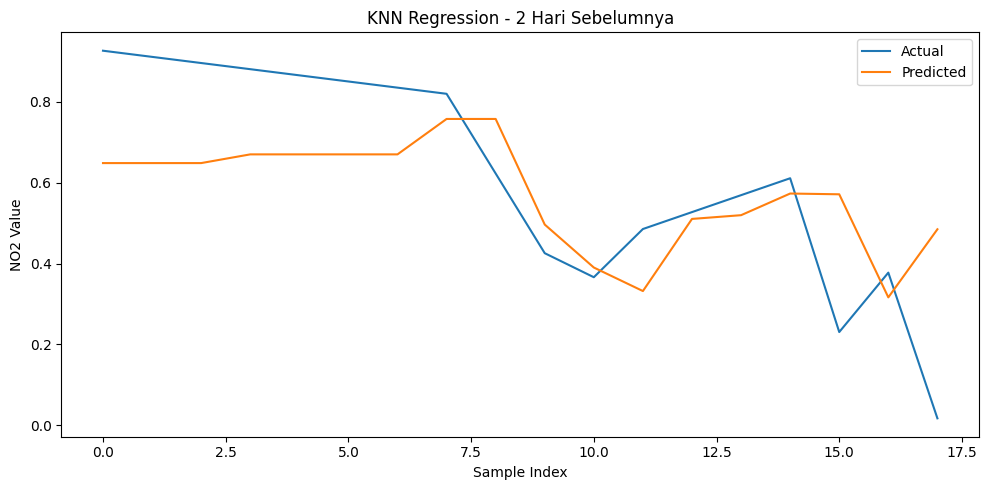

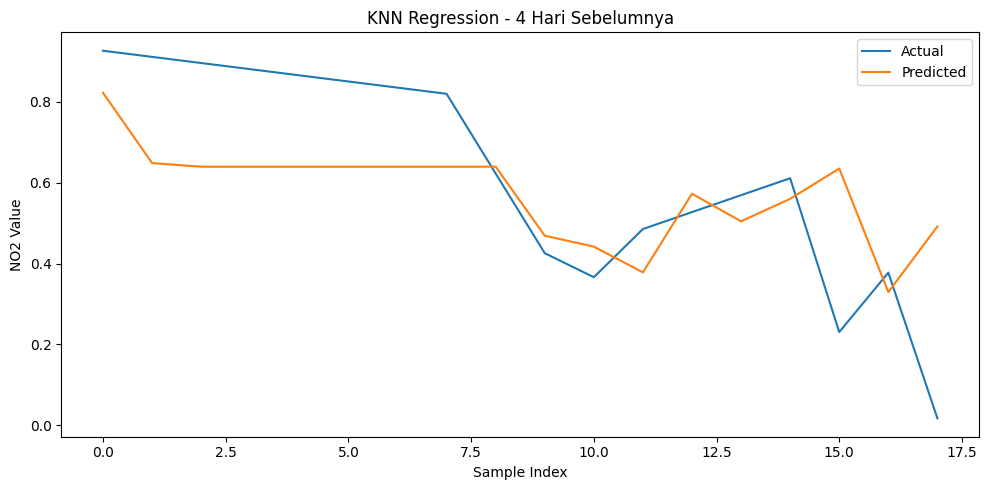

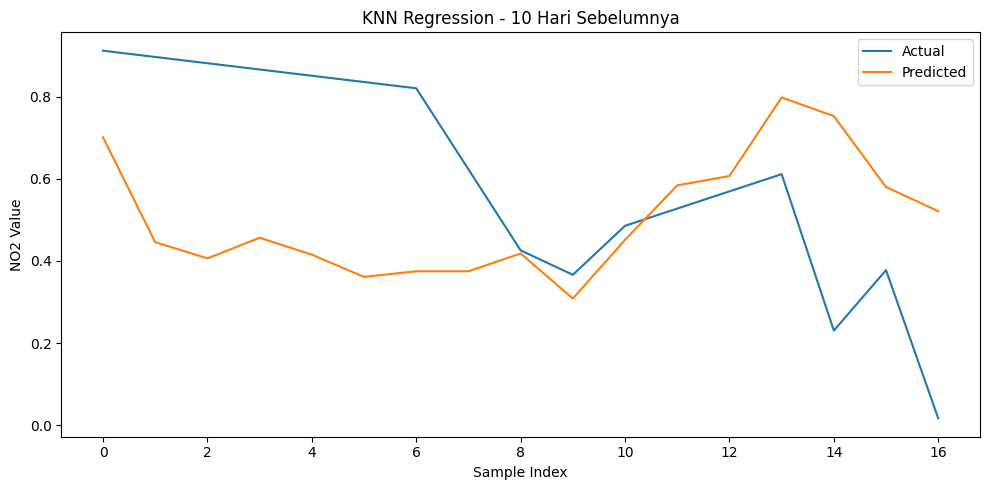

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_prediction(y_test, y_pred, title):
    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(len(y_test)), y_test, label="Actual")
    plt.plot(np.arange(len(y_pred)), y_pred, label="Predicted")
    plt.title(title)
    plt.xlabel("Sample Index")
    plt.ylabel("NO2 Value")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_prediction(
    y_test_2,
    y_pred_2,
    "KNN Regression - 2 Hari Sebelumnya"
)

plot_prediction(
    y_test_4,
    y_pred_4,
    "KNN Regression - 4 Hari Sebelumnya"
)

plot_prediction(
    y_test_10,
    y_pred_10,
    "KNN Regression - 10 Hari Sebelumnya"
)

## Kesimpulan

Data kadar $NO_2$ berhasil dikumpulkan dari Copernicus untuk periode 1 Maret 2026 sampai 31 Mei 2026. Data awal yang berbentuk NetCDF kemudian diproses menjadi data time series harian dengan dua kolom utama, yaitu `date` dan `NO2`.

Pada tahap preprocessing, missing value, missing date, dan outlier ditangani menggunakan interpolasi agar data tetap lengkap berdasarkan urutan waktu. Setelah itu, data time series diubah menjadi data supervised menggunakan konsep lag, yaitu menggunakan data hari-hari sebelumnya untuk memprediksi nilai $NO_2$ pada hari berikutnya.

Berdasarkan hasil evaluasi model KNN Regression, penggunaan 2 hari sebelumnya memberikan hasil paling baik dibandingkan 4 hari dan 10 hari sebelumnya. Model dengan 2 hari sebelumnya menghasilkan nilai RMSE sebesar 0.203501 dan R² sebesar 0.3942. Model dengan 4 hari sebelumnya memiliki hasil yang sedikit lebih rendah, sedangkan model dengan 10 hari sebelumnya menghasilkan performa paling buruk dengan R² bernilai negatif.

Dari hasil tersebut dapat disimpulkan bahwa menambah jumlah hari sebelumnya tidak selalu membuat prediksi menjadi lebih baik. Pada data ini, penggunaan 2 hari sebelumnya lebih sesuai untuk memprediksi kadar $NO_2$. Namun, nilai MAPE pada semua model masih cukup tinggi, sehingga hasil prediksi KNN Regression belum bisa dikatakan sangat akurat dan masih perlu dikembangkan dengan data yang lebih banyak atau metode model lain.